In [3]:
%%capture
%run script_nettoyage.ipynb

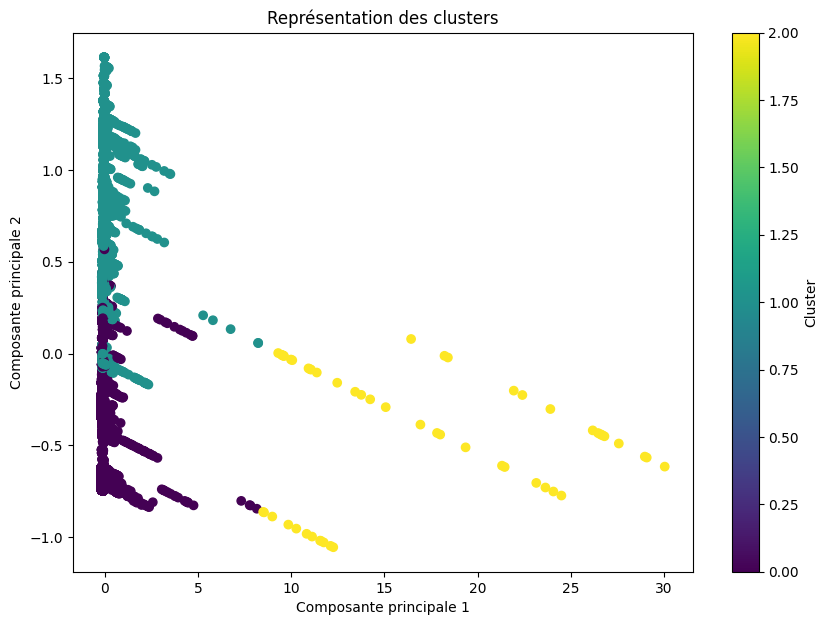

                                      NOM DU MUSEE annee  \
0                                    Musée du Brou  2001   
1            Musée Départemental des Pays De l'Ain  2001   
2  Musée de la Société d'Histoire et d'Archéologie  2001   
3                 Musée Départemental du Revermont  2001   
4                              Musée Archéologique  2001   

                 NOMREG  Statut  freq_net  cluster  
0  AUVERGNE-RHÔNE-ALPES  Ouvert   74056.0        1  
1  AUVERGNE-RHÔNE-ALPES      NA       NaN        1  
2  AUVERGNE-RHÔNE-ALPES  Ouvert     100.0        0  
3  AUVERGNE-RHÔNE-ALPES  Ouvert   22234.0        0  
4  AUVERGNE-RHÔNE-ALPES  Ouvert     204.0        0  


In [10]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import random

random.seed(1)

# copie
df = df_freq_totale.copy()

# colonnes non binaires
colonnes_non_binaires = [
    'REF DU MUSEE', 'NOMREG', 'NOM DU MUSEE', 'VILLE',
    'Fréquentation', 'IDMuseofile', 'annee', 'frequentation',
    'speciale', 'freq_net', 'Statut', 'Domaine_thematique'
]

# colonnes binaires thématiques
colonnes_binaires = [col for col in df.columns if col not in colonnes_non_binaires]

# types de variables
variables_numeriques = ['freq_net']
variables_categorielles = ['annee', 'NOMREG']

# conversions
df['freq_net'] = pd.to_numeric(df['freq_net'], errors='coerce')

# sous-table
X = df[variables_numeriques + variables_categorielles + colonnes_binaires].copy()

# NA
for col in variables_numeriques:
    X[col] = X[col].fillna(X[col].median())

for col in variables_categorielles:
    X[col] = X[col].fillna("Inconnu").astype(str)

for col in colonnes_binaires:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

# prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numeriques),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categorielles),
        ('bin', 'passthrough', colonnes_binaires)
    ]
)

X_prep = preprocessor.fit_transform(X)

# clustering final
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=20)
df['cluster'] = kmeans_final.fit_predict(X_prep)

# réduction en 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_prep)

# graphique
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Représentation des clusters")
plt.colorbar(scatter, label="Cluster")
plt.show()

print(df[['NOM DU MUSEE', 'annee', 'NOMREG', 'Statut', 'freq_net', 'cluster']].head())

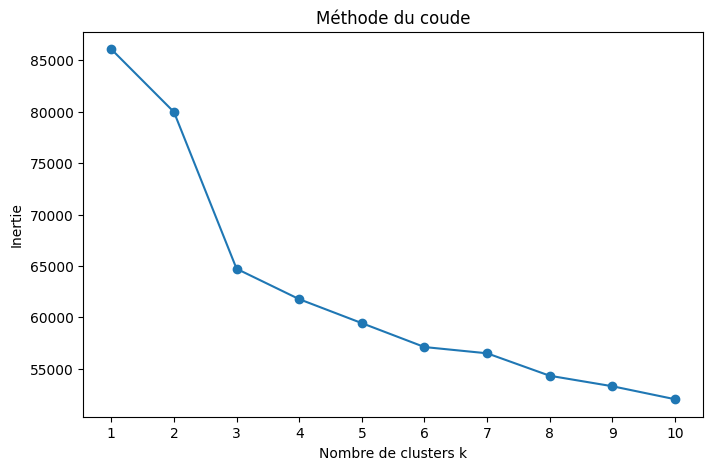

In [9]:
inerties = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_prep)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inerties, marker='o')
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.xticks(K)
plt.show()

In [11]:
df['cluster'].value_counts().sort_index()

cluster
0    11092
1     8709
2       55
Name: count, dtype: int64

In [14]:
resume_num = df.groupby('cluster').agg({
    'freq_net': ['mean', 'median']
})

print(resume_num)

             freq_net           
                 mean     median
cluster                         
0        3.495481e+04    10197.0
1        3.639867e+04    13023.0
2        5.289441e+06  4480081.0


In [20]:
top_pc1 = loadings.assign(importance=loadings['PC1'].abs()) \
                  .sort_values('importance', ascending=False)

top_pc2 = loadings.assign(importance=loadings['PC2'].abs()) \
                  .sort_values('importance', ascending=False)

print("Top 15 PC1")
print(top_pc1[['PC1', 'importance']].head(15))

print("\nTop 15 PC2")
print(top_pc2[['PC2', 'importance']].head(15))

Top 15 PC1
                                             PC1  importance
num__freq_net                           0.995086    0.995086
cat__NOMREG_ÎLE-DE-France               0.070782    0.070782
bin__Arts_decoratifs                    0.042194    0.042194
bin__Beaux_arts                         0.036192    0.036192
bin__Arts de l'Islam                    0.023582    0.023582
bin__Art moderne et contemporain        0.017111    0.017111
bin__Sciences de la nature             -0.014533    0.014533
cat__NOMREG_OCCITANIE                  -0.010207    0.010207
cat__NOMREG_AUVERGNE-RHÔNE-ALPES       -0.009391    0.009391
cat__NOMREG_NOUVELLE-AQUITAINE         -0.008084    0.008084
cat__NOMREG_GRAND EST                  -0.007815    0.007815
cat__NOMREG_BOURGOGNE-FRANCHE-COMTE    -0.007132    0.007132
bin__Asie                               0.006974    0.006974
cat__NOMREG_PROVENCE-ALPES-CÔTE D'AZUR -0.005782    0.005782
cat__NOMREG_NORMANDIE                  -0.005698    0.005698

Top 15 PC2
 

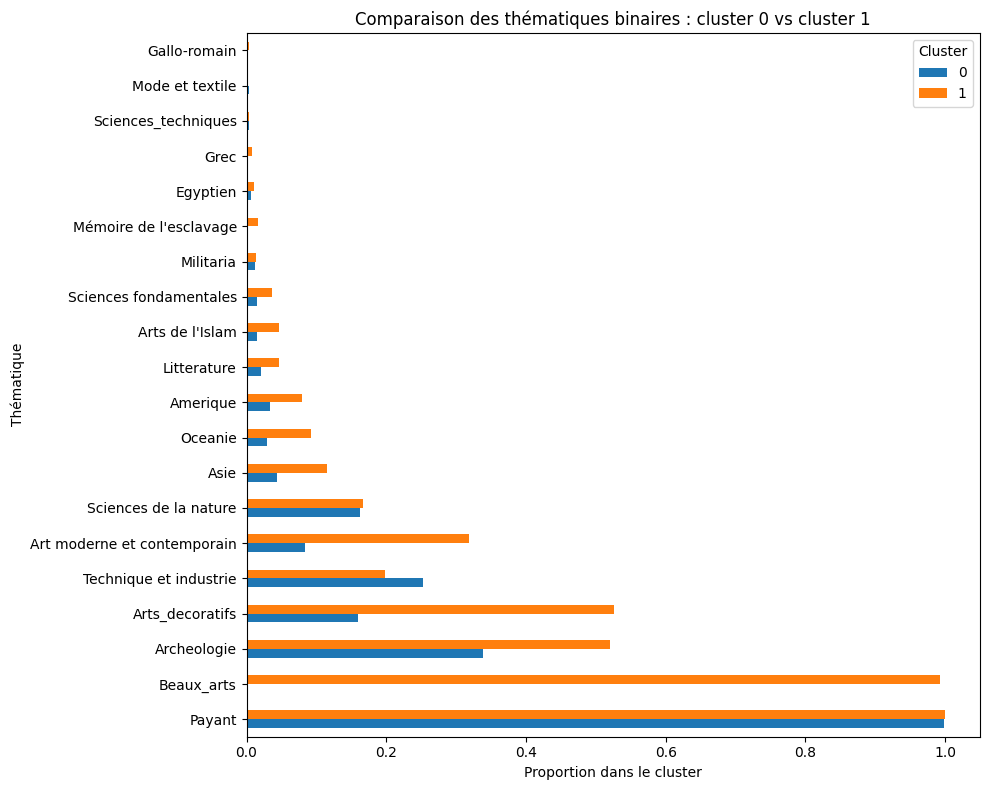

In [21]:
# moyenne des thématiques pour les clusters 0 et 1
themes_01 = df[df['cluster'].isin([0, 1])] \
    .groupby('cluster')[colonnes_binaires] \
    .mean() \
    .T

# option : ne garder que les thématiques les plus présentes au total
themes_01['moyenne_totale'] = themes_01.mean(axis=1)
themes_01 = themes_01.sort_values('moyenne_totale', ascending=False).head(20)
themes_01 = themes_01.drop(columns='moyenne_totale')

# graphique
ax = themes_01.plot(kind='barh', figsize=(10, 8))

plt.xlabel("Proportion dans le cluster")
plt.ylabel("Thématique")
plt.title("Comparaison des thématiques binaires : cluster 0 vs cluster 1")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()